# Pipeline

An ML Pipeline connects your data cleanup steps
(like fixing missing values and turning text categories into numbers)
directly to your machine learning model, turning them into a single automated chain.

Without it: You have to manually do the cleanup during training
and then repeat those exact same steps all over again when you deploy.

With it: You write the steps once. At deployment, the pipeline automatically cleans new raw data
and predicts instantly (asap) without you redoing any work.

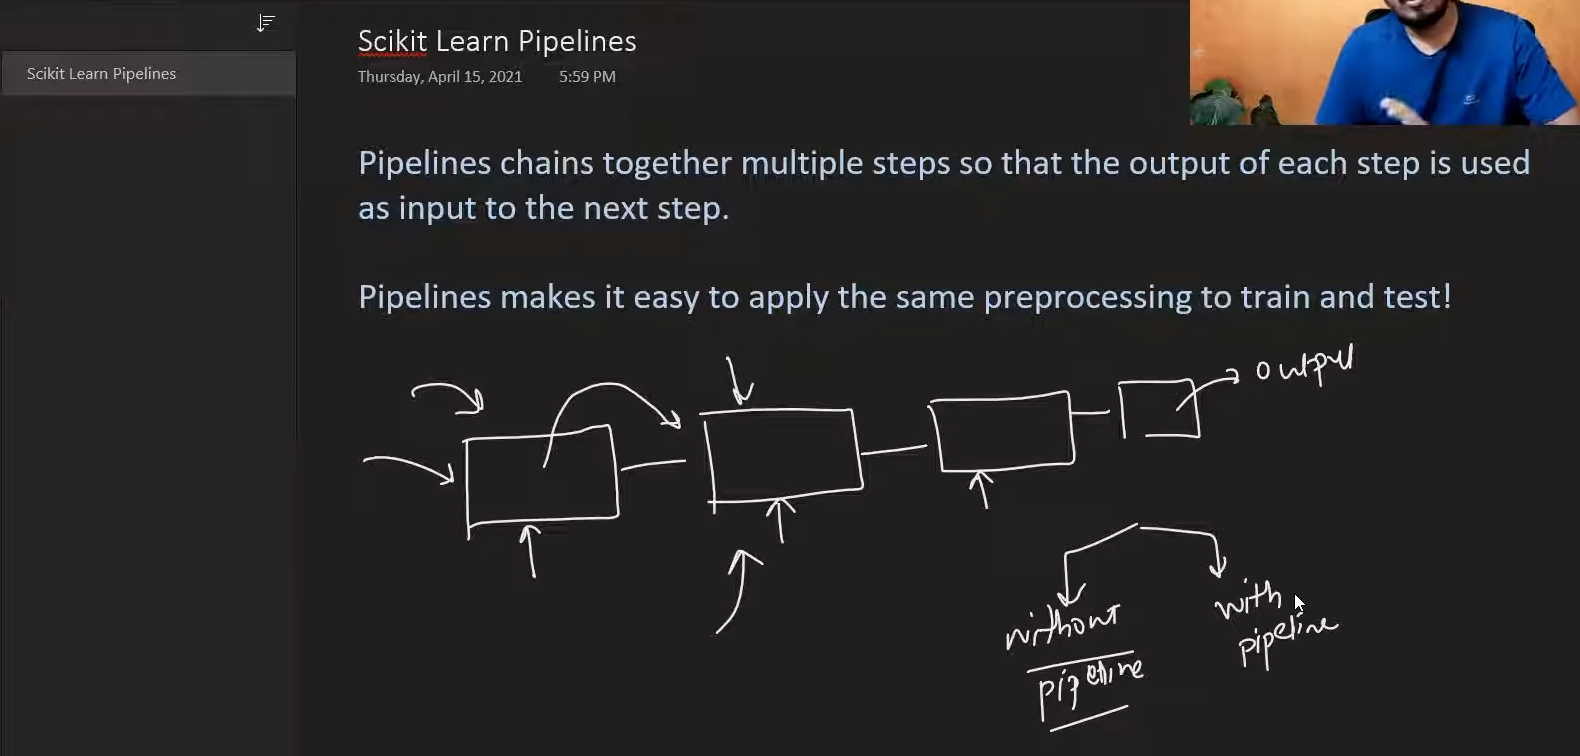

# Titanic without using piplines

In [40]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [41]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
df.drop(columns = ['PassengerId','Ticket','Cabin','Name'],inplace = True)

In [44]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [45]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns = ['Survived']),
                                                 df['Survived'],test_size = 0.2,random_state = 42)

In [46]:
x_train.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [47]:
y_train.head()

331    0
733    0
382    0
704    0
813    0
Name: Survived, dtype: int64

In [48]:
df.isnull().sum()

# so there are missing values so we need to fix these to move forward 

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [49]:
# Apply imputation

# simple imputer =- we use this to use mean, median or the word we want 
# to use at the place of missing values 

si_age = SimpleImputer()
si_embarked = SimpleImputer(strategy = 'most_frequent')

x_train_age = si_age.fit_transform(x_train[['Age']])
x_train_embarked = si_embarked.fit_transform(x_train[['Embarked']])


x_test_age = si_age.transform(x_test[['Age']])
x_test_embarked = si_embarked.transform(x_test[['Embarked']])

In [50]:
x_test_age

array([[29.49884615],
       [31.        ],
       [20.        ],
       [ 6.        ],
       [14.        ],
       [26.        ],
       [29.49884615],
       [16.        ],
       [16.        ],
       [19.        ],
       [37.        ],
       [44.        ],
       [29.49884615],
       [30.        ],
       [36.        ],
       [16.        ],
       [42.        ],
       [29.49884615],
       [27.        ],
       [47.        ],
       [24.        ],
       [34.        ],
       [19.        ],
       [20.        ],
       [29.49884615],
       [10.        ],
       [40.        ],
       [31.        ],
       [ 4.        ],
       [31.        ],
       [19.        ],
       [22.        ],
       [29.49884615],
       [29.49884615],
       [18.        ],
       [27.        ],
       [28.        ],
       [29.49884615],
       [30.        ],
       [29.49884615],
       [21.        ],
       [29.        ],
       [29.49884615],
       [29.49884615],
       [45.        ],
       [16

In [51]:
# OneHotEncoding sex and embarked
# handle unkown means if we get new category in future then ignore the new values and convert in into zeroes

ohe_sex = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
ohe_embarked = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')

x_train_sex = ohe_sex.fit_transform(x_train[['Sex']])
x_train_embarked = ohe_embarked.fit_transform(x_train_embarked)

x_test_sex = ohe_sex.transform(x_test[['Sex']])
x_test_embarked = ohe_embarked.transform(x_test_embarked)

In [52]:
x_train_embarked

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], shape=(712, 3))

In [53]:
x_train.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [54]:
x_train_rem = x_train.drop(columns = ['Sex','Age','Embarked'])

In [55]:
x_test_rem = x_test.drop(columns = ['Sex','Age','Embarked'])

In [56]:
x_train_transformed = np.concatenate((x_train_rem,x_train_age,x_train_sex,x_train_embarked),axis = 1)
x_test_transformed  = np.concatenate((x_test_rem,x_test_age,x_test_sex,x_test_embarked),axis = 1)

In [57]:
x_test_transformed.shape

(179, 10)

In [58]:
clf = DecisionTreeClassifier()
clf.fit(x_train_transformed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred = clf.predict(x_test_transformed)
y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1])

In [60]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.776536312849162

# summary 
fit =  means making our model learn and train but it doesn't change anything 
transform  = means implementing actual change

when we use fit with nomral libraries it is just learning and changing it is not actual training .


x_test = we are not training it we are just using it to change it's missing and categorical 
values.
    
decisiontree = we use this to actually train our model 
when we use fit with decisiontree it is actually training this is the final.
and  by clf.fit(x train, y train) we are training our model .


ypred = we are using only xtest in this  coz training our model(by  decision tree)
fit already knows about the data so it is just using that data to predict our output


accuracy score = we are giving out y test that was untouched and passing our predicted output 
and checking it's accuracy .

In [65]:
import pickle 

In [67]:
pickle.dump(ohe_sex,open('models/ohe_sex.pkl','wb'))
pickle.dump(ohe_embarked, open('models/ohe_embarked.pkl' ,'wb'))
pickle.dump(clf, open('models/clf.pkl' ,'wb'))